In [3]:
%pip install seaborn
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_csv("students_scored.csv")
df.head()

,student_id,age,program,semester,gpa,attendance,assignments_completion,stress_level,sleep_hours,mental_wellbeing,...,distractions,career_clarity,skill_readiness,engagement_score,APS,WWS,PTMS,CRS,SRI,Category
0,S001,20,B.Tech,5,7.8,85,90,7,6,6,...,5,4,6,70,82.75,51.0,67.0,54.0,64.6375,Yellow
1,S002,21,B.Tech,6,8.9,92,95,4,7,8,...,3,6,7,65,91.25,71.0,79.4,65.0,75.9425,Blue
2,S003,19,B.Tech,3,6.2,78,70,8,5,5,...,7,3,4,80,68.00,41.0,49.6,44.0,53.9700,Yellow
3,S004,22,MBA,2,7.1,88,85,6,6,6,...,6,7,6,75,78.75,54.0,59.6,67.0,66.0075,Blue
4,S005,20,B.Tech,4,9.1,95,96,5,7,8,...,4,3,6,60,93.25,68.0,77.0,48.0,71.3125,Blue


In [5]:
features = [
    "APS", "WWS", "PTMS", "CRS", "SRI",
    "stress_level", "sleep_hours",
    "productivity_score", "career_clarity",
    "skill_readiness"
]

X = df[features]

In [6]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

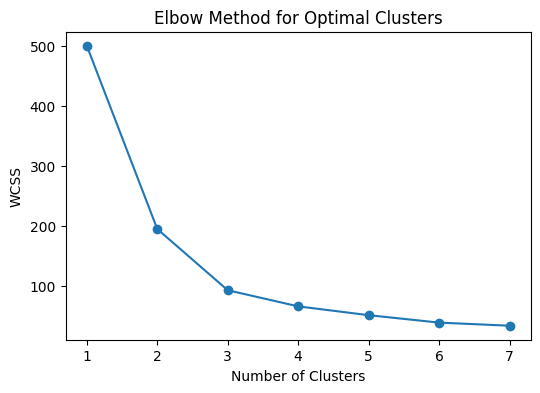

In [7]:
wcss = []

for i in range(1, 8):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,8), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,student_id,age,program,semester,gpa,attendance,assignments_completion,stress_level,sleep_hours,mental_wellbeing,...,career_clarity,skill_readiness,engagement_score,APS,WWS,PTMS,CRS,SRI,Category,Cluster
0,S001,20,B.Tech,5,7.8,85,90,7,6,6,...,4,6,70,82.75,51.0,67.0,54.0,64.6375,Yellow,2
1,S002,21,B.Tech,6,8.9,92,95,4,7,8,...,6,7,65,91.25,71.0,79.4,65.0,75.9425,Blue,3
2,S003,19,B.Tech,3,6.2,78,70,8,5,5,...,3,4,80,68.00,41.0,49.6,44.0,53.9700,Yellow,0
3,S004,22,MBA,2,7.1,88,85,6,6,6,...,7,6,75,78.75,54.0,59.6,67.0,66.0075,Blue,2
4,S005,20,B.Tech,4,9.1,95,96,5,7,8,...,3,6,60,93.25,68.0,77.0,48.0,71.3125,Blue,1


In [9]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df["PC1"] = components[:,0]
df["PC2"] = components[:,1]

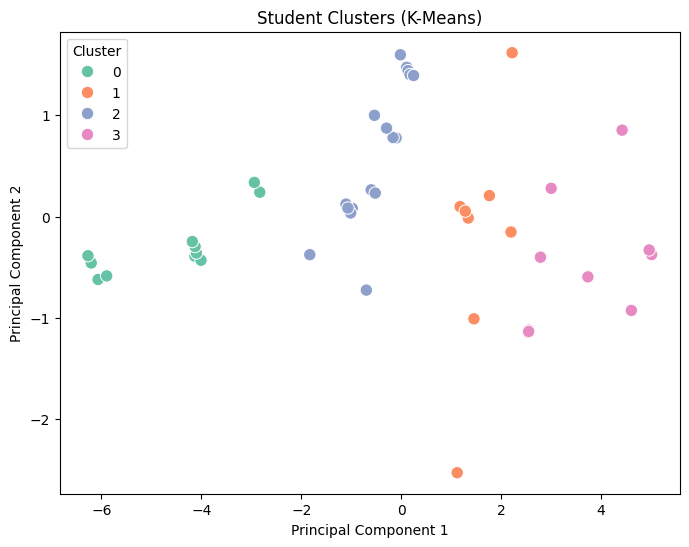

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=80)
plt.title("Student Clusters (K-Means)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [11]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,APS,WWS,PTMS,CRS,SRI,stress_level,sleep_hours,productivity_score,career_clarity,skill_readiness
Cluster,,,,,,,,,,
0,67.863636,38.181818,46.272727,43.545455,52.975000,8.090909,4.636364,4.636364,2.818182,3.818182
1,86.900000,64.400000,72.440000,61.720000,71.317000,5.000000,7.000000,7.300000,5.800000,6.300000
2,79.617647,53.647059,61.670588,60.211765,64.975000,6.117647,6.000000,6.058824,5.705882,5.705882
3,93.041667,75.166667,83.383333,67.066667,78.175417,3.583333,7.416667,8.416667,6.250000,7.500000
